<a href="https://colab.research.google.com/github/Chiya18/OralCancerDetection_Restnet50/blob/main/OralCancerDetection_Restnet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.layers import Conv2D, Dense, Dropout, BatchNormalization, Flatten, MaxPool2D, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from PIL import UnidentifiedImageError


In [ ]:
def load_data(folder_path):
    images = []
    labels = []
    allowed_extensions = ['.jpg', '.jpeg', '.png', '.gif']  # supported extensions

    for label, category in enumerate(['CANCER', 'NON CANCER']):
        category_folder = os.path.join(folder_path, category)
        for file_name in os.listdir(category_folder):
            if os.path.splitext(file_name)[1].lower() in allowed_extensions:
                image_path = os.path.join(category_folder, file_name)   # defines image_path here
                try:
                    image = load_img(image_path, target_size=(224, 224))   # now image_path is available
                    image_array = img_to_array(image)
                    image_array = preprocess_input(image_array)
                    images.append(image_array)
                    labels.append(label)
                except UnidentifiedImageError:
                    print(f"Skipping file: {image_path} - UnidentifiedImageError")
            else:
                print(f"Skipping file: {file_name} - Invalid file type")
    return np.array(images), np.array(labels)
folder_path = "/content/drive/MyDrive/archive/Oral cancer Dataset 2.0/OC Dataset kaggle new"
images, labels = load_data(folder_path)


/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Skipping file: /content/drive/MyDrive/archive/Oral cancer Dataset 2.0/OC Dataset kaggle new/CANCER/101.jpeg - UnidentifiedImageError
Skipping file: /content/drive/MyDrive/archive/Oral cancer Dataset 2.0/OC Dataset kaggle new/CANCER/200.jpeg - UnidentifiedImageError
Skipping file: /content/drive/MyDrive/archive/Oral cancer Dataset 2.0/OC Dataset kaggle new/CANCER/273.jpeg - UnidentifiedImageError
Skipping file: /content/drive/MyDrive/archive/Oral cancer Dataset 2.0/OC Dataset kaggle new/CANCER/317.jpeg - UnidentifiedImageError
Skipping file: /content/drive/MyDrive/archive/Oral cancer Dataset 2.0/OC Dataset kaggle new/CANCER/328.jpeg - UnidentifiedImageError
Skipping file: /content/drive/MyDrive/archive/Oral cancer Dataset 2.0/OC Dataset kaggle new/CANCER/481.jpeg - UnidentifiedImageError
Skipping file: /content/drive/MyDrive/archive/Oral cancer Dataset 2.0/OC Dataset kaggle new/CANCER/485.jpeg - UnidentifiedImageError
Skipping file: /content/drive/MyDrive/archive/Oral cancer Dataset 2.0

In [ ]:
images[0]

array([[[   3.060997 ,   -4.7789993,   -2.6800003],
        [  -8.939003 ,  -16.779    ,  -14.68     ],
        [ -11.939003 ,  -19.779    ,  -17.68     ],
        ...,
        [  52.060997 ,   46.221    ,   48.32     ],
        [  80.061    ,   78.221    ,   75.32     ],
        [ 116.061    ,  114.221    ,  111.32     ]],

       [[ -23.939003 ,  -31.779    ,  -29.68     ],
        [ -32.939003 ,  -40.779    ,  -38.68     ],
        [ -30.939003 ,  -39.779    ,  -35.68     ],
        ...,
        [  45.060997 ,   39.221    ,   41.32     ],
        [  74.061    ,   72.221    ,   69.32     ],
        [ 118.061    ,  116.221    ,  113.32     ]],

       [[ -19.939003 ,  -27.779    ,  -25.68     ],
        [ -24.939003 ,  -32.779    ,  -30.68     ],
        [ -18.939003 ,  -28.779    ,  -21.68     ],
        ...,
        [  47.060997 ,   38.221    ,   42.32     ],
        [  75.061    ,   70.221    ,   70.32     ],
        [ 119.061    ,  115.221    ,  112.32     ]],

       ...,

      

In [ ]:
labels[0]

np.int64(0)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42, shuffle=True)

In [ ]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False   # Freeze base model weights

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')   # Binary Classification
])


In [ ]:
model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0001),
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, min_lr=1e-6)
checkpoint = tf.keras.callbacks.ModelCheckpoint('/content/best_resnet50_model.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)


In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr, checkpoint]
)


Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - accuracy: 0.5749 - loss: 0.8361 - precision: 0.5581 - recall: 0.7629
Epoch 1: val_accuracy improved from -inf to 0.84043, saving model to /content/best_resnet50_model.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 32s 726ms/step - accuracy: 0.5771 - loss: 0.8344 - precision: 0.5592 - recall: 0.7643 - val_accuracy: 0.8404 - val_loss: 0.3943 - val_precision: 0.7593 - val_recall: 0.9535 - learning_rate: 1.0000e-04
Epoch 2/20
23/24 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.7792 - loss: 0.5240 - precision: 0.7382 - recall: 0.8655
Epoch 2: val_accuracy improved from 0.84043 to 0.88298, saving model to /content/best_resnet50_model.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 20s 144ms/step - accuracy: 0.7805 - loss: 0.5220 - precision: 0.7386 - recall: 0.8668 - val_accuracy: 0.8830 - val_loss: 0.3190 - val_precision: 0.8265 - val_recall: 0.9419 - learning_rate: 1.0000e-04
Epoch 3/20
23/24 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.8283 - loss: 0.4649 - p

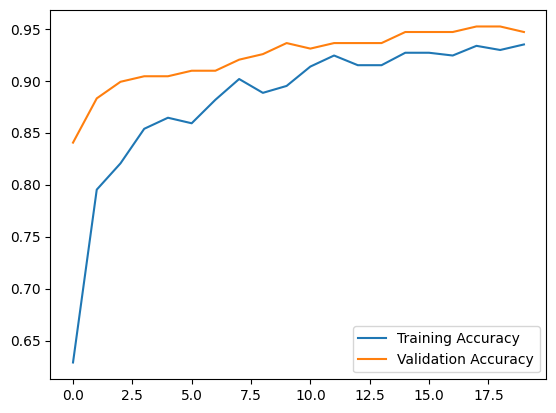

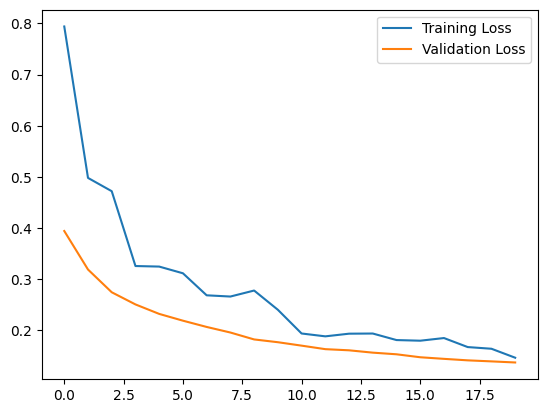

In [ ]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()


In [ ]:
from google.colab import files
from PIL import Image
import io

uploaded = files.upload()

for fn in uploaded.keys():
    img = Image.open(io.BytesIO(uploaded[fn]))
    img = img.resize((224, 224))
    # Convert the image to RGB format to remove the alpha channel
    img = img.convert('RGB')
    img_array = np.array(img)
    img_array = preprocess_input(img_array)   # very important for ResNet
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    print(f"Prediction for {fn}: {prediction[0][0]}")
    if prediction[0][0] > 0.5:
        print("Result: Non-Cancer")
    else:
        print("Result: Cancer")

Saving ALU_Gates.png to ALU_Gates.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Prediction for ALU_Gates.png: 0.9485352635383606
Result: Non-Cancer
